# Twitter News Detection Model Training

## Project Title
Algorithmic Fact-Verification Networks

## Objective
This notebook trains a simple machine learning model to classify news articles as Real or Fake using a Fake News Dataset.

## Model Approach
We use TF-IDF to convert text into numbers, then train a Logistic Regression model for binary classification.

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

## Read and Load Dataset

In [2]:
df = pd.read_csv("../data/twitter_bot_dataset/bot_detection_data.csv")

In [3]:
df.head()

,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,Hashtags
0,132131,flong,Station activity person against natural majori...,85,1,2353,False,1,Adkinston,2020-05-11 15:29:50,NaN
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,True,0,Sanderston,2022-11-26 05:18:10,both live
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,True,0,Harrisonfurt,2022-08-08 03:16:54,phone ahead
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,True,1,Martinezberg,2021-08-14 22:27:05,ever quickly new I
4,704441,noah87,Animal sign six data good or.,26,3,8438,False,1,Camachoville,2020-04-13 21:24:21,foreign mention


## Inspect labels

In [4]:
df.columns

Index(['User ID', 'Username', 'Tweet', 'Retweet Count', 'Mention Count',
       'Follower Count', 'Verified', 'Bot Label', 'Location', 'Created At',
       'Hashtags'],
      dtype='object')

In [5]:
df.shape

(50000, 11)

## Check Target Distribution

In [6]:
df["Bot Label"].value_counts()

Bot Label
1    25018
0    24982
Name: count, dtype: int64

## Check Missing Values

In [7]:
df.isnull().sum()

User ID              0
Username             0
Tweet                0
Retweet Count        0
Mention Count        0
Follower Count       0
Verified             0
Bot Label            0
Location             0
Created At           0
Hashtags          8341
dtype: int64

## Check Data Types

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   User ID         50000 non-null  int64 
 1   Username        50000 non-null  object
 2   Tweet           50000 non-null  object
 3   Retweet Count   50000 non-null  int64 
 4   Mention Count   50000 non-null  int64 
 5   Follower Count  50000 non-null  int64 
 6   Verified        50000 non-null  bool  
 7   Bot Label       50000 non-null  int64 
 8   Location        50000 non-null  object
 9   Created At      50000 non-null  object
 10  Hashtags        41659 non-null  object
dtypes: bool(1), int64(5), object(5)
memory usage: 3.9+ MB


## Handle Missing Hashtags

In [9]:
df["Hashtags"] = df["Hashtags"].fillna("")

## Remove Unnecessary Column

In [10]:
df = df.drop(columns=["User ID"])

## Create Combined Text Feature

In [11]:
df["text_features"] = (
    df["Tweet"] + " " +
    df["Username"] + " " +
    df["Location"] + " " +
    df["Hashtags"]
)

## Check the features

In [12]:
df[["text_features", "Bot Label"]].head()

,text_features,Bot Label
0,Station activity person against natural majori...,1
1,Authority research natural life material staff...,0
2,Manage whose quickly especially foot none to g...,0
3,Just cover eight opportunity strong policy whi...,1
4,Animal sign six data good or. noah87 Camachovi...,1


Unlike LIAR or Fake News this dataset has more than just text, so we will prepare:

Text features → TF-IDF
Numerical features → scaled values
Combine them → train model

## Extract Account Age Feature

In [13]:
df["Created At"] = pd.to_datetime(df["Created At"])

current_date = pd.Timestamp.now()

df["Account Age"] = (
    current_date - df["Created At"]
).dt.days

## Check New Feature

In [14]:
df[["Created At", "Account Age"]].head()

,Created At,Account Age
0,2020-05-11 15:29:50,2255
1,2022-11-26 05:18:10,1327
2,2022-08-08 03:16:54,1437
3,2021-08-14 22:27:05,1795
4,2020-04-13 21:24:21,2283


## Select Numerical Features

In [15]:
numeric_features = df[
    [
        "Retweet Count",
        "Mention Count",
        "Follower Count",
        "Verified",
        "Account Age"
    ]
].copy()

## Convert Verified Boolean

In [16]:
numeric_features["Verified"] = numeric_features["Verified"].astype(int)

## Define Target

In [17]:
y = df["Bot Label"]

In [18]:
df[["Created At", "Account Age"]].head()

,Created At,Account Age
0,2020-05-11 15:29:50,2255
1,2022-11-26 05:18:10,1327
2,2022-08-08 03:16:54,1437
3,2021-08-14 22:27:05,1795
4,2020-04-13 21:24:21,2283


In [19]:
numeric_features.head()

,Retweet Count,Mention Count,Follower Count,Verified,Account Age
0,85,1,2353,0,2255
1,55,5,9617,1,1327
2,6,2,4363,1,1437
3,54,5,2242,1,1795
4,26,3,8438,0,2283


## Train/Test Split

In [20]:
from sklearn.model_selection import train_test_split

X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    df["text_features"],
    numeric_features,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
## TF-IDF Text Vectorization

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_text_train_tfidf = tfidf.fit_transform(X_text_train)

X_text_test_tfidf = tfidf.transform(X_text_test)

In [23]:
## Scale Numerical Features

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_num_train_scaled = scaler.fit_transform(X_num_train)

X_num_test_scaled = scaler.transform(X_num_test)

In [25]:
## Combine Text + Numerical Features

In [26]:
from scipy.sparse import hstack

X_train_final = hstack(
    [
        X_text_train_tfidf,
        X_num_train_scaled
    ]
)

X_test_final = hstack(
    [
        X_text_test_tfidf,
        X_num_test_scaled
    ]
)

In [27]:
## Check Shape

In [28]:
print(X_train_final.shape)
print(X_test_final.shape)

(40000, 5005)
(10000, 5005)


In [29]:
## Train Logistic Regression Model

In [30]:
bot_model = LogisticRegression(
    max_iter=1000
)

bot_model.fit(
    X_train_final,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
## Make Predictions

In [32]:
y_pred = bot_model.predict(X_test_final)

In [33]:
## Check Confusion Matrix

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2488 2508]
 [2485 2519]]


In [35]:
## Evaluate Model

In [36]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 50.07%

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.50      0.50      4996
           1       0.50      0.50      0.50      5004

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



## Test Bot Detection Model

In [37]:
sample_texts = [
    "Breaking news today about government policies and elections.",
    "Win free money now!!! Click this link and share with everyone.",
    "I had a great day at the park with my friends.",
    "Follow me for amazing offers and unlimited rewards."
]


sample_numeric = pd.DataFrame([
    [20, 1, 1500, 0, 2000],
    [500, 20, 100, 0, 100],
    [5, 0, 300, 1, 2500],
    [300, 15, 50, 0, 50]
], columns=[
    "Retweet Count",
    "Mention Count",
    "Follower Count",
    "Verified",
    "Account Age"
])

## Transform Test Data

In [38]:
sample_text_tfidf = tfidf.transform(sample_texts)

In [39]:
sample_numeric_scaled = scaler.transform(sample_numeric)

In [40]:
sample_final = hstack([
    sample_text_tfidf,
    sample_numeric_scaled
])

## Predict

In [44]:
sample_predictions = bot_model.predict(sample_final)

for text, prediction in zip(sample_texts, sample_predictions):
    result = "BOT" if prediction == 1 else "HUMAN"
    
    print("\nTweet:")
    print(text)
    print("Prediction:", result)


Tweet:
Breaking news today about government policies and elections.
Prediction: HUMAN

Tweet:
Win free money now!!! Click this link and share with everyone.
Prediction: BOT

Tweet:
I had a great day at the park with my friends.
Prediction: HUMAN

Tweet:
Follow me for amazing offers and unlimited rewards.
Prediction: BOT


## Save the Model

In [45]:
joblib.dump(bot_model,"../models/twitter_bot_dataset_model.pkl")
joblib.dump(tfidf,"../models/twitter_bot_dataset_tfidf.pkl")
joblib.dump(scaler,"../models/twitter_bot_dataset_scaler.pkl")

print("Twitter Bot files saved successfully.")

Twitter Bot files saved successfully.


In [43]:
## PCA Visualization of Text Features

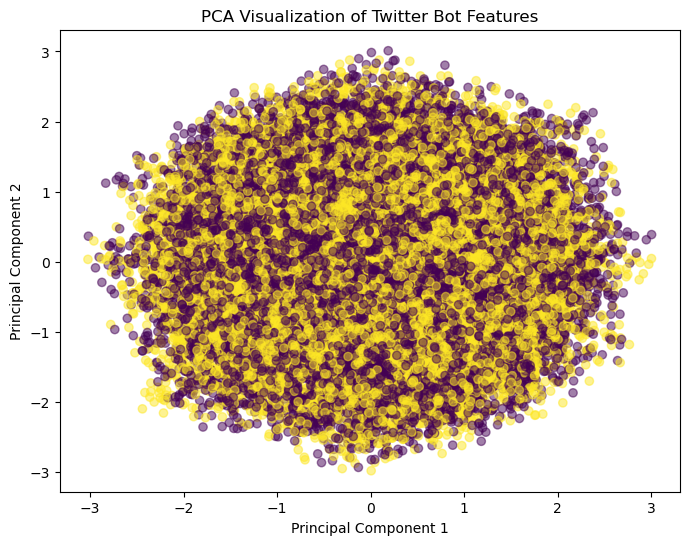

In [44]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# Convert sparse matrix
X_dense = X_train_final.toarray()


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_dense)


plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_train,
    alpha=0.5
)

plt.title("PCA Visualization of Twitter Bot Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()